In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
BASE = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project'
df = pd.read_csv(os.path.join(BASE, 'data', 'kepler_clean.csv'))
TARGET = 'koi_disposition'

COLOR_MAP = {
    'CONFIRMED': '#4CAF50',
    'CANDIDATE': '#F44336',
    'FALSE POSITIVE': '#FF9800'
}

SCATTER PLOT - RADIUS vs PERIOD

In [2]:
fig = px.scatter(
    df,
    x='koi_period',
    y='koi_prad',
    color=TARGET,
    color_discrete_map=COLOR_MAP,
    hover_data=['koi_teq', 'koi_insol', 'koi_score'],
    log_x = True,
    log_y = True,
    title = 'Planet Radius vs Orbital Period (log-log scale)',
    labels = {
        'koi_period' : 'Orbital Period (days) - log scale',
        'koi_radius' : 'Planet Radius (Earth Radii) - log scale',
        TARGET : 'Disposition'
    },
    opacity = 1,
    template = 'plotly_dark'
)
fig.update_traces(marker=dict(size=4))
fig.write_html(os.path.join(BASE, 'outputs', 'p3_scatter_radius_period.html'))
fig.show()

INTERACTIVE HISTOGRAM - PLANET RADIUS BY CLASS


In [3]:
plot_df = df[['koi_prad', TARGET]].dropna()
plot_df = plot_df[plot_df['koi_prad'] > 0]

# Define bins manually on log scale
bins = np.logspace(
    np.log10(plot_df['koi_prad'].min()),
    np.log10(plot_df['koi_prad'].max()),
    81  # 80 bins
)

COLOR_MAP = {
    'CONFIRMED':      '#4CAF50',
    'FALSE POSITIVE': '#F44336',
    'CANDIDATE':      '#FF9800'
}

fig = go.Figure()

for disposition, color in COLOR_MAP.items():
    subset = plot_df[plot_df[TARGET] == disposition]['koi_prad']
    counts, edges = np.histogram(subset, bins=bins)
    fig.add_trace(go.Bar(
        x=edges[:-1],          # left edge of each bin
        y=counts,
        name=disposition,
        marker_color=color,
        opacity=0.75,
        width=np.diff(edges),  # each bar is exactly its bin width
        offset=0
    ))

fig.update_layout(
    barmode='overlay',
    title='Distribution of Planet Radius by Disposition Class',
    xaxis=dict(
        title='Planet Radius (Earth radii) — log scale',
        type='log'
    ),
    yaxis_title='Count',
    template='plotly_dark',
    legend_title='Disposition',
    bargap=0
)

fig.write_html(os.path.join(BASE, 'outputs', 'p3_histogram_radius.html'))
fig.show()

INTERACTIVE BOX PLOTS - MULTIPLE FEATURES

In [4]:
features_to_plot = {
    'koi_prad' : 'Planet Radius (Earth Radii)',
    'koi_insol' : 'Insolation Flux (Earth flux)',
    'koi_teq' : 'Equilibrium Temperature (K)',
    'koi_model_snr' : 'Signal-to-noise Ratio',
    'koi_score' : 'Disposition Score (0-1)',
    'koi_duration' : 'Transit Duration (hours)'
}

fig = make_subplots(rows=2, cols=3,
                    subplot_titles=list(features_to_plot.values()))

disp_groups = ['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
row_col = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]

for idx, (col, title) in enumerate(features_to_plot.items()):
    r, c = row_col[idx]
    for disp in disp_groups:
        subset = df[df[TARGET] == disp][col].dropna()
        fig.add_trace(
            go.Box(y=subset, name=disp, marker_color=COLOR_MAP[disp],
                   showlegend=(idx == 0), legendgroup=disp),
            row=r, col=c
        )

fig.update_layout(
    title_text = 'Key Features - Box Plots by Disposition Class',
    template = 'plotly_dark',
    height=700,
    boxmode='group'
)
fig.write_html(os.path.join(BASE, 'outputs', 'p3_boxplots_interactive.html'))
fig.show()

HEATMAP CORRELATION MATRIX (INTERACTIVE Plotly)

In [5]:
KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_score', 'koi_depth', 'koi_duration', 'koi_impact'
]

corr = df[KEY_FEATURES].corr().round(2)

fig = go.Figure(data=go.Heatmap(
    z = corr.values,
    x = corr.columns.tolist(),
    y = corr.columns.tolist(),
    colorscale = 'RdBu',
    zmid = 0,
    text = corr.values,
    texttemplate = '%{text}',
    textfont = {'size': 9},
    hoverongaps=False
))

fig.update_layout(
    title = 'Feature Correlation Heatmap',
    template = 'plotly_dark',
    height=600, width=750
)
fig.write_html(os.path.join(BASE, 'outputs', 'p3_correlation_heatmap.html'))
fig.show()

PAIR PLOT - TOP FEATURES (seaborn Stats)

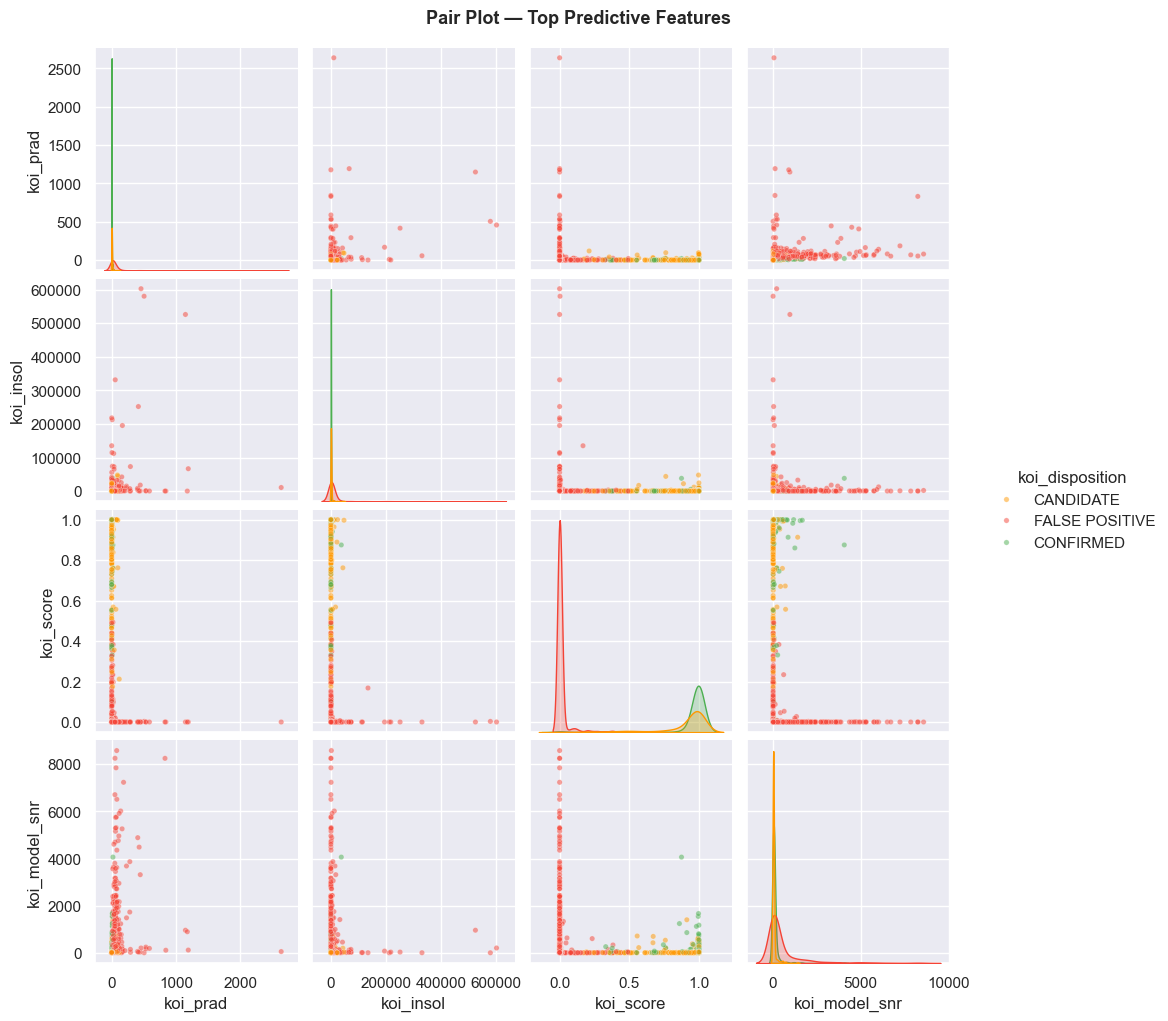

In [6]:
top4 = ['koi_prad', 'koi_insol', 'koi_score', 'koi_model_snr', TARGET]
pair_df = df[top4].dropna().sample(n=min(1500, len(df)), random_state=42)

g = sns.pairplot(
    pair_df, hue=TARGET,
    palette = {'CONFIRMED': '#4CAF50', 'FALSE POSITIVE': '#F44336', 'CANDIDATE' : '#FF9800'},
    plot_kws = dict(alpha=0.5, s=15),
    diag_kind='kde'
)

g.figure.suptitle('Pair Plot — Top Predictive Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig(os.path.join(BASE, 'outputs', 'p3_pairplot.png'), dpi=120, bbox_inches='tight')
plt.show()